<a href="https://colab.research.google.com/github/Johnwaka1212/PIPELINE/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#John Wamalwa
#25/02504
Take Home CAT 2: Applying Unstructured Data Analytics in Computer Vision
DATE OF SUBMISSION: 14th MARCH 2026

## Dataset Source

Dataset: Fruits Fresh and Rotten for Classification

Source:
https://www.kaggle.com/datasets/swoyam2609/fresh-and-stale-classification

The dataset contains images of fruits and vegetables categorized into fresh and rotten classes.
Tomato images from this dataset were used to train a convolutional neural network (CNN) model
to perform an image classification task.
.

In [22]:
!pip install kaggle


Downloading kaggle dataset

In [42]:
!kaggle datasets download -d swoyam2609/fresh-and-stale-classification

Dataset URL: https://www.kaggle.com/datasets/swoyam2609/fresh-and-stale-classification
License(s): Community Data License Agreement - Permissive - Version 1.0
100% 2.83G/2.84G [00:39<00:00, 249MB/s]
100% 2.84G/2.84G [00:39<00:00, 77.8MB/s]


#Extracting dataset

In [43]:
import zipfile

with zipfile.ZipFile("fresh-and-stale-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")


### Loading dataset for CNN

In [46]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/dataset/Train",
    image_size=(224,224),
    batch_size=32
)


Found 23619 files belonging to 18 classes.


Checking dataset structure

In [45]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)


dataset
dataset/dataset
dataset/dataset/Train
dataset/dataset/Train/freshbittergroud
dataset/dataset/Train/rottenapples
dataset/dataset/Train/rottentomato
dataset/dataset/Train/rottencucumber
dataset/dataset/Train/rottenpotato
dataset/dataset/Train/rottencapsicum
dataset/dataset/Train/freshbanana
dataset/dataset/Train/freshpotato
dataset/dataset/Train/freshapples
dataset/dataset/Train/rottenbanana
dataset/dataset/Train/rottenoranges
dataset/dataset/Train/rottenokra
dataset/dataset/Train/rottenbittergroud
dataset/dataset/Train/freshcucumber
dataset/dataset/Train/freshcapsicum
dataset/dataset/Train/freshoranges
dataset/dataset/Train/freshokra
dataset/dataset/Train/freshtomato
dataset/dataset/Test
dataset/dataset/Test/freshtamto
dataset/dataset/Test/rottentamto
dataset/dataset/Test/rottenapples
dataset/dataset/Test/rottencucumber
dataset/dataset/Test/freshbanana
dataset/dataset/Test/freshpatato
dataset/dataset/Test/freshapples
dataset/dataset/Test/rottenpatato
dataset/dataset/Test/rottenb

#Checking the detected classes

In [47]:
print(train_data.class_names)


['freshapples', 'freshbanana', 'freshbittergroud', 'freshcapsicum', 'freshcucumber', 'freshokra', 'freshoranges', 'freshpotato', 'freshtomato', 'rottenapples', 'rottenbanana', 'rottenbittergroud', 'rottencapsicum', 'rottencucumber', 'rottenokra', 'rottenoranges', 'rottenpotato', 'rottentomato']


#Filtering only the tomato classes

In [50]:
import os
import shutil

source_train = "dataset/dataset/Train"
source_test = "dataset/dataset/Test"

target_train = "tomato_dataset/train"
target_test = "tomato_dataset/test"

# Train names
train_classes = ["freshtomato", "rottentomato"]

# Test names (with typo in dataset)
test_classes = ["freshtamto", "rottentamto"]

for c in train_classes:
    os.makedirs(os.path.join(target_train, c), exist_ok=True)

for c in ["freshtomato","rottentomato"]:
    os.makedirs(os.path.join(target_test, c), exist_ok=True)

# Copy train images
for c in train_classes:
    for file in os.listdir(os.path.join(source_train, c)):
        shutil.copy(
            os.path.join(source_train, c, file),
            os.path.join(target_train, c, file)
        )

# Copy test images (fix naming)
mapping = {
    "freshtamto":"freshtomato",
    "rottentamto":"rottentomato"
}

for wrong, correct in mapping.items():
    for file in os.listdir(os.path.join(source_test, wrong)):
        shutil.copy(
            os.path.join(source_test, wrong, file),
            os.path.join(target_test, correct, file)
        )


#Loading my tomato dataset
#Intepretation
This means that the datasets contain two classes: fresh tomatoes and rotten tomatoes enabling the CNN model to learn from the training data and then be evaluated on unseen images from the test dataset, helping it to measure how well the model generalizes to new data.

In [51]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "tomato_dataset/train",
    image_size=(224,224),
    batch_size=32
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "tomato_dataset/test",
    image_size=(224,224),
    batch_size=32
)


Found 3683 files belonging to 2 classes.
Found 608 files belonging to 2 classes.


#Lets Visualize our Tomato Dataset

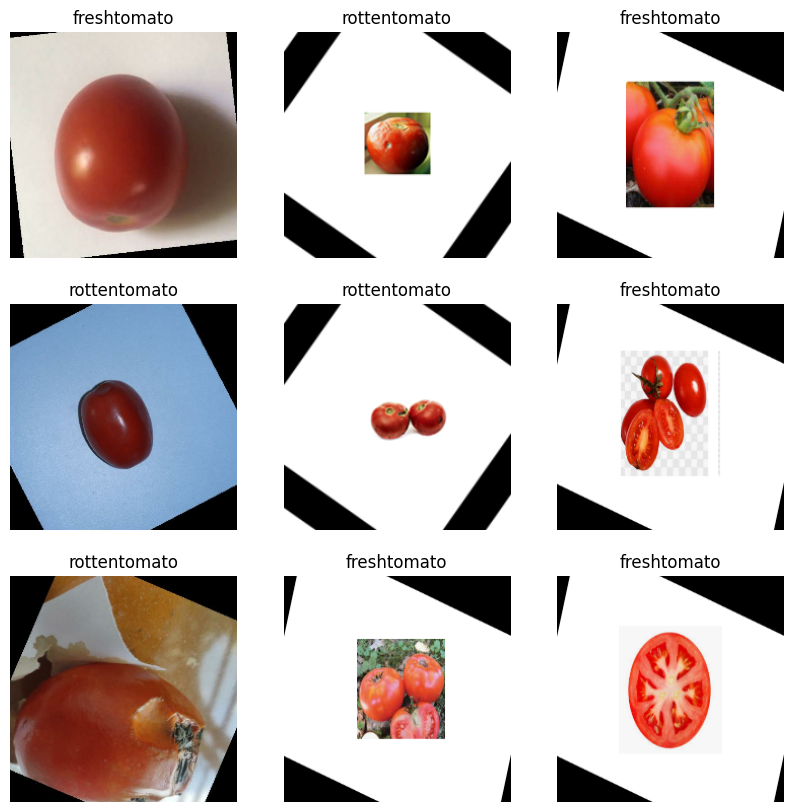

In [56]:
plt.figure(figsize=(10,10))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")


#Graph of Dataset Distribution Before we Train our CNN.

#Results outputs and interpretations
The graph shows the number of images available for
each class in the training dataset which contains
two classes:fresh tomatoes and rotten tomatoes.

Visualization assists us to confirm that both classes are
well represented for training a balanced classification
model.


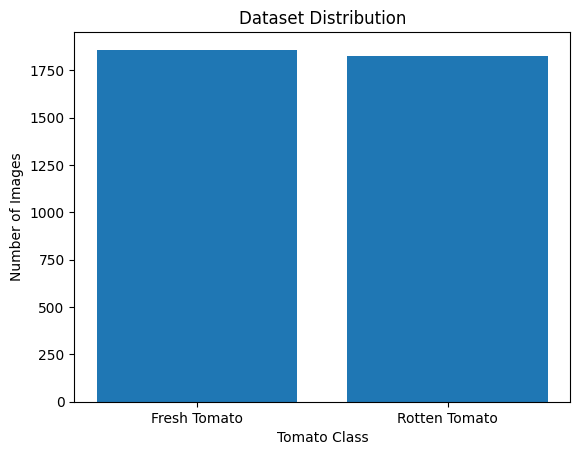

In [58]:
import os
import matplotlib.pyplot as plt

fresh_count = len(os.listdir("tomato_dataset/train/freshtomato"))
rotten_count = len(os.listdir("tomato_dataset/train/rottentomato"))

classes = ["Fresh Tomato", "Rotten Tomato"]
counts = [fresh_count, rotten_count]

plt.bar(classes, counts)

plt.title("Dataset Distribution")
plt.xlabel("Tomato Class")
plt.ylabel("Number of Images")

plt.show()


#Lets train now our CNN
## CNN Model Construction

Here the model is only being constructed and compiled.The model consists of convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification.The CNN architecture was defined using TensorFlow/Keras.


In [52]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(2,activation="softmax")
])


#Compiling our model
#Intepretation
During this step, compiling the model is being done to configure the learning process before training begins..

The Adam optimizer was used to adjust the models weights during training,
while the binary cross-entropy loss function was selected because the task involves binary classification (fresh tomatoes vs rotten tomatoes). Accuracy was used as the evaluation metric to measure the model's performance.



In [53]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


#Lets train our model now

#Results outputs and interpretations
From Epoch 2 to Epoch 10, the CNN model shows steady improvement in its ability to classify tomato images. The training accuracy increases from approximately 85% to 99.8%, while the training loss consistently decreases, indicating that the model is learning meaningful patterns from the data.This suggests that the model performs very well on unseen test data and is able to correctly distinguish between fresh tomatoes and rotten tomatoes.

Overall, the results demonstrate that the CNN successfully learned visual features such as color and texture differences that characterize the two tomato classes.


In [54]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)


Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 335s 3s/step - accuracy: 0.7364 - loss: 1.8049 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.8531 - loss: 0.2921 - val_accuracy: 1.0000 - val_loss: 4.7843e-04
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 360s 3s/step - accuracy: 0.8760 - loss: 0.2519 - val_accuracy: 1.0000 - val_loss: 1.8123e-04
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.9245 - loss: 0.1727 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 371s 3s/step - accuracy: 0.9558 - loss: 0.1122 - val_accuracy: 1.0000 - val_loss: 4.5772e-05
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.9669 - loss: 0.0906 - val_accuracy: 1.0000 - val_loss: 2.0513e-04
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.9857 - loss: 0.0420 - val_accuracy: 1.0000 - val_loss: 4.4644e-07
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 361s 3s/step - accuracy: 0.9876 - los

#Evaluating the models performance

#Results outputs and interpretations
The trained CNN model was evaluated using the test dataset containing
608 tomato images. The evaluation results show that the model achieved
an accuracy of 100% with a very small loss value.Indicating that the CNN was able to correctly classify all test images as either fresh tomatoes or rotten tomatoes. The model learned
important visual features such as color differences, texture patterns,
and surface damage that distinguish fresh tomatoes from rotten ones.
#conclusion
The model having achieved a perfect accuracy on the test dataset,
further evaluation on a more diverse dataset may be necessary to ensure that the model generalizes well to new real-world tomato images.


In [55]:
model.evaluate(test_data)


19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 767ms/step - accuracy: 1.0000 - loss: 1.3221e-07


[3.770035448269482e-07, 1.0]

#Graph Accuracy  after Training the model

#Results outputs and interpretations
The CNN was trained for 10 epochs using
3,683 tomato images for training and 608 images for testing.

The model's training accuracy increased from approximately 73% in the
first epoch to nearly 99.8% by the final epoch. At the same time, the
training loss decreased significantly, indicating that the model
improved its predictions during training.

The validation accuracy remained at 100% throughout the training
process, showing that the model successfully generalized to unseen
test images.

These results indicate that the CNN was able to effectively learn
visual differences between fresh and rotten tomatoes, including
changes in color, texture, and surface appearance.


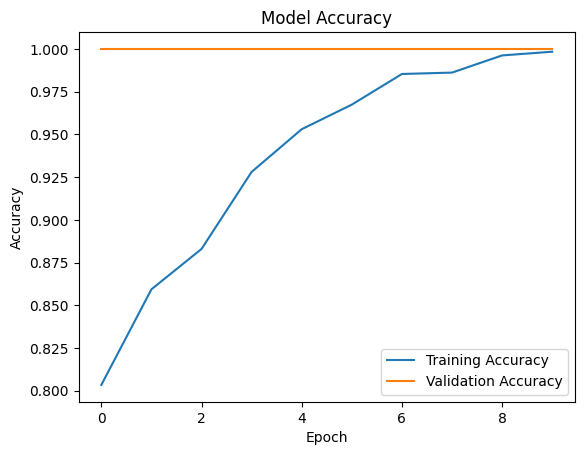

In [57]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()
